**Цель:**
1. Изучить структуру датасета
2. Проверить качество данных
3. Исследовать распределение признаков
4. Выявить взаимосвязи факторов риска диабета
5. Обосновать выбор признаков для модели

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent / 'src'
sys.path.append(str(ROOT))

from preprocessing import load_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = load_data()
df.head()

,GenHlth,BMI,Age,HighBP,PhysActivity,HeartDiseaseorAttack,DiffWalk,Diabetes_binary
0,3.0,26.0,4.0,1.0,1.0,0.0,0.0,0.0
1,3.0,26.0,12.0,1.0,0.0,0.0,0.0,0.0
2,1.0,26.0,13.0,0.0,1.0,0.0,0.0,0.0
3,3.0,28.0,11.0,1.0,1.0,0.0,0.0,0.0
4,2.0,29.0,8.0,0.0,1.0,0.0,0.0,0.0


**Размер датасета**

In [3]:
df.shape

(70692, 8)

**Проверка пропущенных значений**

In [4]:
df.isnull().sum()

GenHlth                 0
BMI                     0
Age                     0
HighBP                  0
PhysActivity            0
HeartDiseaseorAttack    0
DiffWalk                0
Diabetes_binary         0
dtype: int64

**Описание числовых признаков**

In [5]:
df.describe()

,GenHlth,BMI,Age,HighBP,PhysActivity,HeartDiseaseorAttack,DiffWalk,Diabetes_binary
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,2.837082,29.856985,8.584055,0.563458,0.703036,0.147810,0.252730,0.500000
std,1.113565,7.113954,2.852153,0.495960,0.456924,0.354914,0.434581,0.500004
min,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,25.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,29.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.500000
75%,4.000000,33.000000,11.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,5.000000,98.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Баланс классов**

In [6]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

In [7]:
# %%
df["Diabetes_binary"].value_counts(normalize=True)

Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

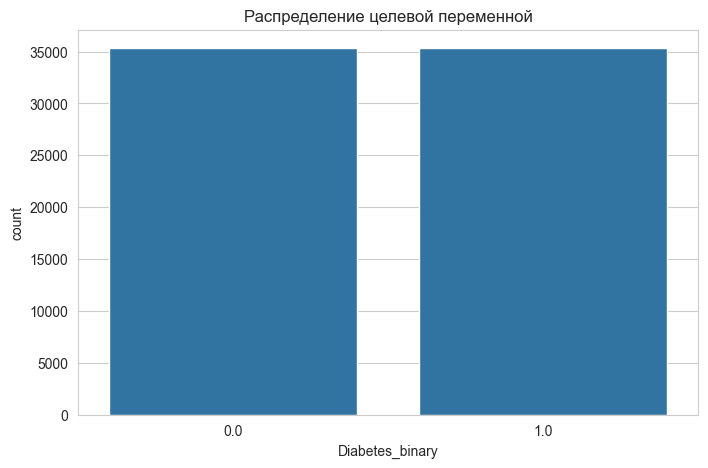

In [8]:
sns.countplot(data=df, x="Diabetes_binary")
plt.title("Распределение целевой переменной")
plt.show()

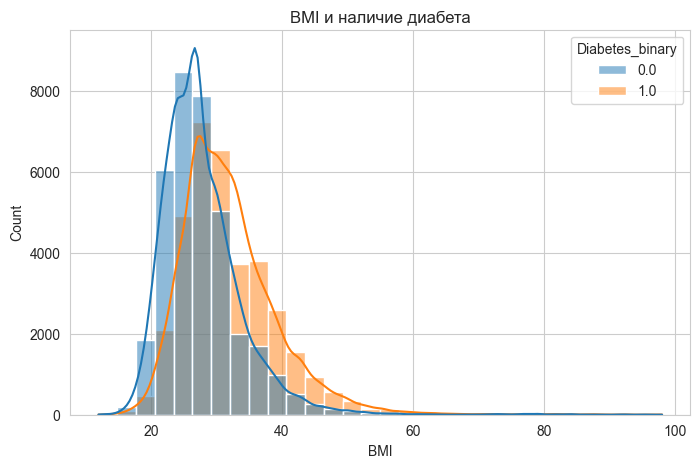

In [9]:
sns.histplot(data=df, x="BMI", hue="Diabetes_binary", kde=True, bins=30)
plt.title("BMI и наличие диабета")
plt.show()

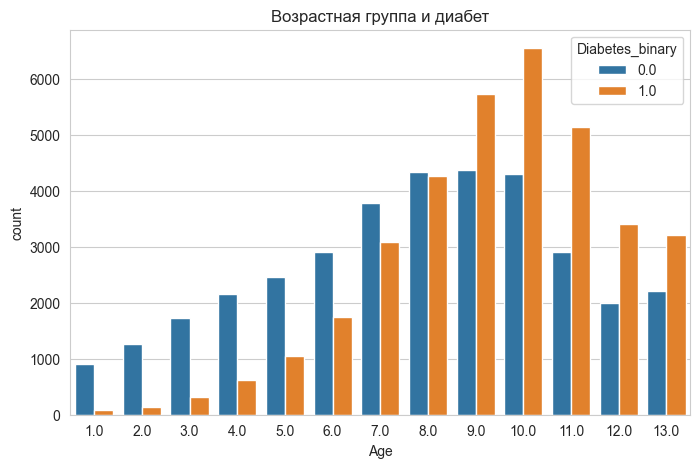

In [10]:
sns.countplot(data=df, x="Age", hue="Diabetes_binary")
plt.title("Возрастная группа и диабет")
plt.show()

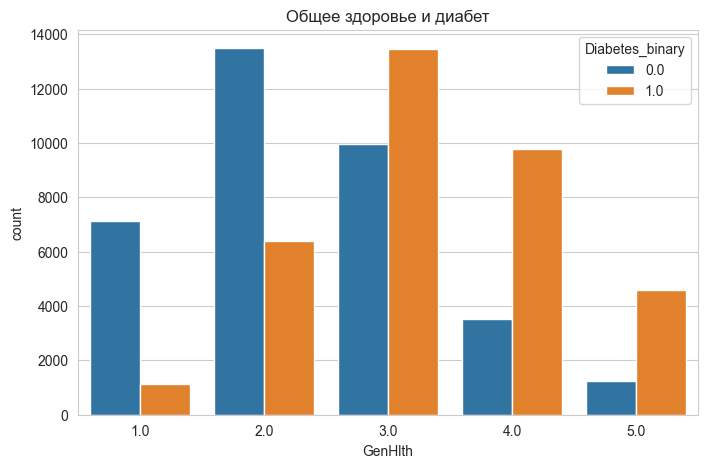

In [11]:
sns.countplot(data=df, x="GenHlth", hue="Diabetes_binary")
plt.title("Общее здоровье и диабет")
plt.show()

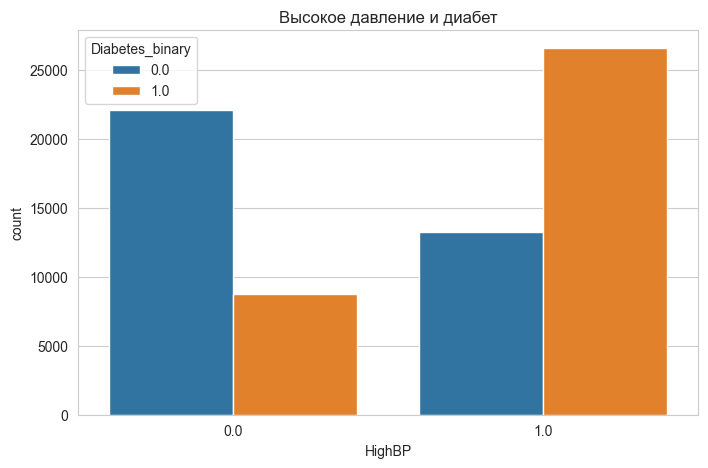

In [12]:
sns.countplot(data=df, x="HighBP", hue="Diabetes_binary")
plt.title("Высокое давление и диабет")
plt.show()

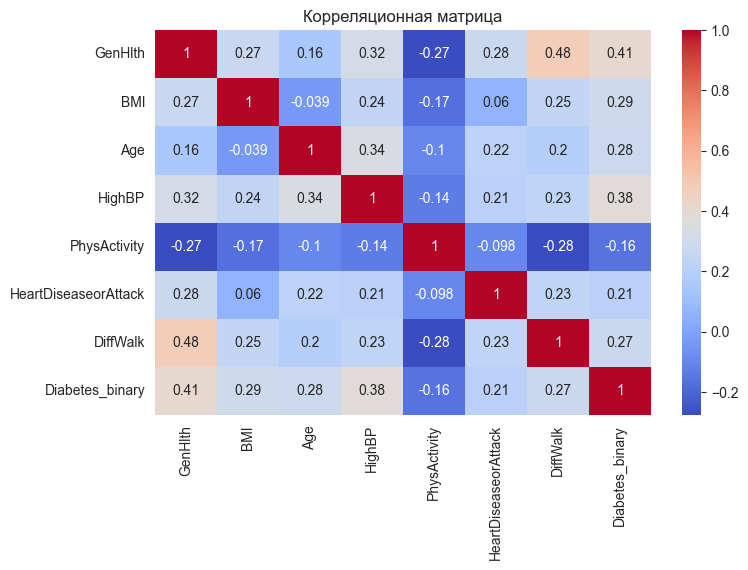

In [13]:
# %%
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Корреляционная матрица")

plt.show()

**Выводы:**
1. Датасет не содержит пропущенных значений.
2. Классы распределены сбалансированно.
3. Повышенный BMI связан с диабетом.
4. Возраст увеличивает вероятность заболевания.
5. Плохое общее состояние здоровья и высокое давление являются значимыми факторами риска.
6. Выбранные признаки имеют медицинскую и статистическую значимость.